# RNN Binary Operations: Learning Logic from Sequences

**What we'll learn:**
- How RNNs process sequences to learn logical operations
- Building a sequence-to-sequence model for bit-level computation
- Comparing learning difficulty across different binary operations (AND, OR, NOT, XOR)
- Creating a clean test bed for hyperparameter experimentation

**Why this matters:**
Binary operations provide a perfect controlled environment to understand RNN learning dynamics. XOR is famously harder to learn than AND/OR, demonstrating how network architectures handle non-linear relationships. This notebook gives you a minimal, performant baseline for experimenting with sequence models.

## 1. The Task

We'll teach RNNs to perform **bitwise operations** on binary strings:

```
Input:  [1, 0, 1, 1]
AND     [0, 1, 1, 0]
Output: [0, 0, 1, 0]  # Element-wise AND
```

The RNN reads both input sequences and outputs the result bit-by-bit. This tests:
- **Memory**: Tracking two sequences in parallel
- **Logic**: Learning the operation's truth table
- **Generalization**: Working on unseen bit patterns

## 2. Configuration

All hyperparameters in one place for easy experimentation.

In [ ]:
CONFIG = {
    # Reproducibility
    'seed': 42,  # Random seed for reproducibility
    
    # Data
    'sequence_length': 8,  # Length of input bit strings
    'train_samples': 5000,  # Number of training examples per operation
    'val_samples': 1000,  # Number of validation examples per operation
    'batch_size': 128,  # Number of samples per batch
    'num_workers': 0,  # Number of workers for data loading
    
    # Model
    'hidden_size': 64,  # RNN hidden state dimension
    'num_layers': 2,  # Number of stacked RNN layers
    'dropout': 0.1,  # Dropout probability between layers
    'rnn_type': 'RNN',  # RNN variant: 'RNN', 'LSTM', or 'GRU'
    
    # Training
    'learning_rate': 0.001,  # Optimizer learning rate
    'max_epochs': 50,  # Maximum number of training epochs
    'early_stop_patience': 10,  # Epochs to wait before early stopping
    
    # Operations to learn
    'operations': ['AND', 'OR', 'NOT', 'XOR'],  # Binary operations to train on
}

## 3. Setup

Initialize random seed and detect available hardware.

In [2]:
from aiml_notebooks import set_seed, get_device

set_seed(CONFIG['seed'])
device = get_device()

print(f"Using device: {device}")
print(f"Training on operations: {', '.join(CONFIG['operations'])}")

Using MPS (Metal Performance Shaders) for GPU acceleration
Using device: mps
Training on operations: AND, OR, NOT, XOR


## 4. Generate Binary Operation Data

Create synthetic datasets for each binary operation. Each sample consists of two input sequences and one output sequence.

In [3]:
import torch
import numpy as np

def generate_binary_data(operation, num_samples, seq_length, seed=None):
    """
    Generate input-output pairs for binary operations.
    
    Args:
        operation: One of 'AND', 'OR', 'NOT', 'XOR'
        num_samples: Number of examples to generate
        seq_length: Length of bit sequences
        seed: Random seed for reproducibility
    
    Returns:
        input_a: (num_samples, seq_length) - First operand
        input_b: (num_samples, seq_length) - Second operand (unused for NOT)
        output: (num_samples, seq_length) - Result of operation
    """
    if seed is not None:
        np.random.seed(seed)
    
    # Generate random binary sequences
    input_a = np.random.randint(0, 2, size=(num_samples, seq_length))
    input_b = np.random.randint(0, 2, size=(num_samples, seq_length))
    
    # Apply operation
    if operation == 'AND':
        output = input_a & input_b
    elif operation == 'OR':
        output = input_a | input_b
    elif operation == 'NOT':
        output = 1 - input_a  # Bitwise NOT
        input_b = np.zeros_like(input_a)  # NOT is unary, pad second input
    elif operation == 'XOR':
        output = input_a ^ input_b
    else:
        raise ValueError(f"Unknown operation: {operation}")
    
    return (
        torch.tensor(input_a, dtype=torch.float32),
        torch.tensor(input_b, dtype=torch.float32),
        torch.tensor(output, dtype=torch.float32)
    )

# Test data generation
test_a, test_b, test_out = generate_binary_data('XOR', 3, 4, seed=42)
print("Sample XOR examples:")
for i in range(3):
    print(f"{test_a[i].numpy().astype(int)} XOR {test_b[i].numpy().astype(int)} = {test_out[i].numpy().astype(int)}")

Sample XOR examples:
[0 1 0 0] XOR [0 0 1 0] = [0 1 1 0]
[0 1 0 0] XOR [1 1 1 0] = [1 0 1 0]
[0 1 0 0] XOR [1 0 1 1] = [1 1 1 1]


## 5. Create PyTorch Dataset

Wrap our data in a PyTorch Dataset for efficient batching.

In [4]:
from torch.utils.data import Dataset

class BinaryOpDataset(Dataset):
    """Dataset for binary operation sequences."""
    
    def __init__(self, input_a, input_b, output):
        """
        Args:
            input_a: (num_samples, seq_length) - First operand
            input_b: (num_samples, seq_length) - Second operand
            output: (num_samples, seq_length) - Operation result
        """
        self.input_a = input_a
        self.input_b = input_b
        self.output = output
    
    def __len__(self):
        return len(self.input_a)
    
    def __getitem__(self, idx):
        # Concatenate both inputs as separate channels
        # Shape: (seq_length, 2) - each timestep has 2 features
        inputs = torch.stack([self.input_a[idx], self.input_b[idx]], dim=1)
        return inputs, self.output[idx]

# Create a small test dataset
test_a, test_b, test_out = generate_binary_data('AND', 100, CONFIG['sequence_length'], seed=42)
test_dataset = BinaryOpDataset(test_a, test_b, test_out)

print(f"Dataset size: {len(test_dataset)}")
sample_input, sample_output = test_dataset[0]
print(f"Input shape: {sample_input.shape}  # (seq_length, 2)")
print(f"Output shape: {sample_output.shape}  # (seq_length,)")

Dataset size: 100
Input shape: torch.Size([8, 2])  # (seq_length, 2)
Output shape: torch.Size([8])  # (seq_length,)


## 6. Visualize the Task

See what the RNN needs to learn by examining examples from each operation.

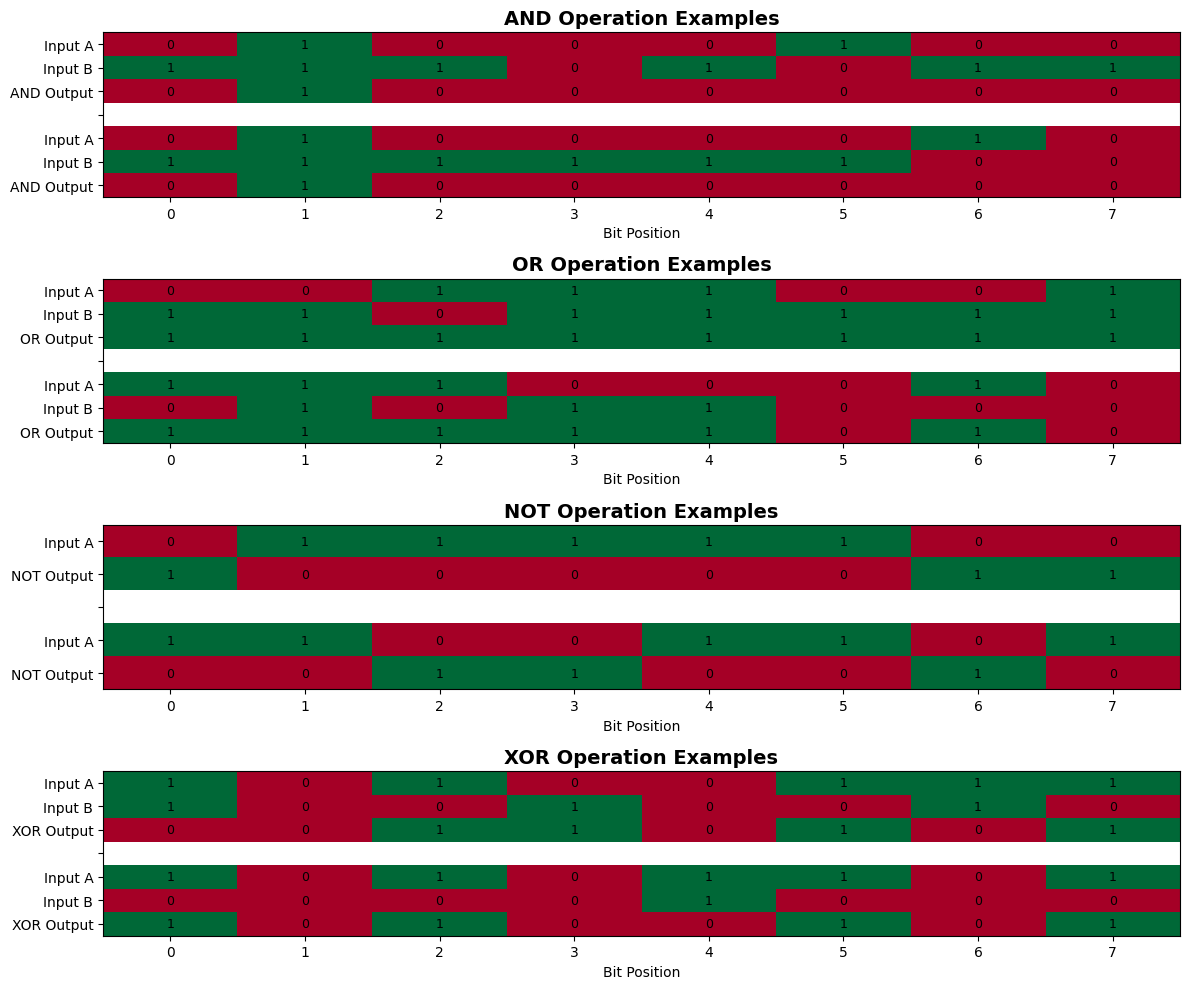

In [5]:
import matplotlib.pyplot as plt

def visualize_operation_examples(operations, num_examples=3, seq_length=8):
    """Show examples of each binary operation."""
    fig, axes = plt.subplots(len(operations), 1, figsize=(12, 2.5 * len(operations)))
    if len(operations) == 1:
        axes = [axes]
    
    for idx, op in enumerate(operations):
        a, b, out = generate_binary_data(op, num_examples, seq_length, seed=42+idx)
        
        ax = axes[idx]
        ax.set_title(f"{op} Operation Examples", fontsize=14, fontweight='bold')
        
        # Create a grid showing inputs and outputs
        display_data = []
        labels = []
        
        for i in range(num_examples):
            display_data.append(a[i].numpy())
            labels.append(f"Input A")
            
            if op != 'NOT':
                display_data.append(b[i].numpy())
                labels.append(f"Input B")
            
            display_data.append(out[i].numpy())
            labels.append(f"{op} Output")
            
            # Add separator
            if i < num_examples - 1:
                display_data.append(np.full(seq_length, np.nan))
                labels.append("")
        
        display_array = np.array(display_data)
        
        # Plot as heatmap
        im = ax.imshow(display_array, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels)
        ax.set_xlabel('Bit Position', fontsize=10)
        ax.grid(False)
        
        # Add text annotations
        for i in range(len(display_data)):
            for j in range(seq_length):
                if not np.isnan(display_array[i, j]):
                    text = ax.text(j, i, int(display_array[i, j]),
                                 ha="center", va="center", color="black", fontsize=9)
    
    plt.tight_layout()
    plt.show()

visualize_operation_examples(CONFIG['operations'], num_examples=2, seq_length=CONFIG['sequence_length'])

## 7. Build the RNN Model

Create a sequence-to-sequence RNN using PyTorch Lightning. The model:
- Reads two bit sequences in parallel (as 2 input features)
- Processes them through RNN layers
- Outputs a prediction for each position in the sequence

In [6]:
import torch.nn as nn
import lightning as L

class BinaryOpRNN(L.LightningModule):
    """RNN for learning binary operations on sequences."""
    
    def __init__(
        self,
        hidden_size=CONFIG['hidden_size'],
        num_layers=CONFIG['num_layers'],
        dropout=CONFIG['dropout'],
        rnn_type=CONFIG['rnn_type'],
        learning_rate=CONFIG['learning_rate']
    ):
        super().__init__()
        self.save_hyperparameters()
        
        # RNN takes 2 input features (two operands) at each timestep
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(
                input_size=2,
                hidden_size=hidden_size,
                num_layers=num_layers,
                dropout=dropout if num_layers > 1 else 0,
                batch_first=True
            )
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(
                input_size=2,
                hidden_size=hidden_size,
                num_layers=num_layers,
                dropout=dropout if num_layers > 1 else 0,
                batch_first=True
            )
        elif rnn_type == 'RNN':
            self.rnn = nn.RNN(
                input_size=2,
                hidden_size=hidden_size,
                num_layers=num_layers,
                dropout=dropout if num_layers > 1 else 0,
                batch_first=True,
                nonlinearity='tanh'
            )
        else:
            raise ValueError(f"Unknown RNN type: {rnn_type}")
        
        # Output layer: map hidden state to binary prediction (0 or 1)
        self.fc = nn.Linear(hidden_size, 1)
        
        # Binary cross entropy loss (with logits for numerical stability)
        self.criterion = nn.BCEWithLogitsLoss()
    
    def forward(self, x):
        """
        Args:
            x: (batch_size, seq_length, 2) - Input sequences
        
        Returns:
            (batch_size, seq_length) - Binary predictions (logits)
        """
        # Pass through RNN
        rnn_out, _ = self.rnn(x)  # (batch_size, seq_length, hidden_size)
        
        # Project to output space
        logits = self.fc(rnn_out).squeeze(-1)  # (batch_size, seq_length)
        
        return logits
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        
        # Calculate accuracy (convert logits to predictions)
        preds = (torch.sigmoid(logits) > 0.5).float()
        acc = (preds == y).float().mean()
        
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', acc, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        
        # Calculate accuracy
        preds = (torch.sigmoid(logits) > 0.5).float()
        acc = (preds == y).float().mean()
        
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)

# Create model and show architecture
model = BinaryOpRNN()
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

BinaryOpRNN(
  (rnn): LSTM(2, 64, num_layers=2, batch_first=True, dropout=0.1)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (criterion): BCEWithLogitsLoss()
)

Total parameters: 50,753


## 8. Test Forward Pass

Verify the model produces correct output shapes before training.

In [7]:
# Create a small batch for testing
test_input = torch.randn(4, CONFIG['sequence_length'], 2)  # (batch=4, seq_len, features=2)
test_output = model(test_input)

print(f"Input shape: {test_input.shape}  # (batch_size, seq_length, 2)")
print(f"Output shape: {test_output.shape}  # (batch_size, seq_length)")
print(f"\nSample predictions (logits): {test_output[0].detach().numpy()}")
print(f"After sigmoid: {torch.sigmoid(test_output[0]).detach().numpy()}")

Input shape: torch.Size([4, 8, 2])  # (batch_size, seq_length, 2)
Output shape: torch.Size([4, 8])  # (batch_size, seq_length)

Sample predictions (logits): [0.07752351 0.07828833 0.07609101 0.0771253  0.07897075 0.08031155
 0.07907332 0.07882835]
After sigmoid: [0.51937115 0.5195621  0.5190136  0.5192718  0.5197324  0.5200671
 0.51975805 0.5196969 ]


## 9. Create Training Function

Build a reusable function to train models on different operations.

In [8]:
from torch.utils.data import DataLoader
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import EarlyStopping

def train_binary_op_model(operation, config):
    """
    Train a model on a specific binary operation.
    
    Args:
        operation: Binary operation name ('AND', 'OR', 'NOT', 'XOR')
        config: Configuration dictionary
    
    Returns:
        Trained model and trainer
    """
    print(f"\n{'='*60}")
    print(f"Training on {operation} operation")
    print(f"{'='*60}")
    
    # Generate data
    train_a, train_b, train_out = generate_binary_data(
        operation, config['train_samples'], config['sequence_length'], seed=config['seed']
    )
    val_a, val_b, val_out = generate_binary_data(
        operation, config['val_samples'], config['sequence_length'], seed=config['seed'] + 1
    )
    
    # Create datasets
    train_dataset = BinaryOpDataset(train_a, train_b, train_out)
    val_dataset = BinaryOpDataset(val_a, val_b, val_out)
    
    # Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=config['batch_size'],
        shuffle=True,
        num_workers=config['num_workers']
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=config['batch_size'],
        shuffle=False,
        num_workers=config['num_workers']
    )
    
    # Create model
    model = BinaryOpRNN(
        hidden_size=config['hidden_size'],
        num_layers=config['num_layers'],
        dropout=config['dropout'],
        rnn_type=config['rnn_type'],
        learning_rate=config['learning_rate']
    )
    
    # Setup logger and callbacks
    logger = CSVLogger('logs', name=f'binary_op_{operation.lower()}')
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=config['early_stop_patience'],
        mode='min',
        verbose=False
    )
    
    # Create trainer
    trainer = L.Trainer(
        max_epochs=config['max_epochs'],
        accelerator='auto',
        devices=1,
        logger=logger,
        callbacks=[early_stop],
        enable_progress_bar=True,
        enable_model_summary=False
    )
    
    # Train
    trainer.fit(model, train_loader, val_loader)
    
    return model, trainer, logger

print("Training function ready!")

Training function ready!


## 10. Train on All Operations

Train separate models for each binary operation and collect results.

In [9]:
# Train models for each operation
results = {}

for operation in CONFIG['operations']:
    model, trainer, logger = train_binary_op_model(operation, CONFIG)
    results[operation] = {
        'model': model,
        'trainer': trainer,
        'logger': logger
    }

print("\n" + "="*60)
print("Training Complete!")
print("="*60)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


GPU available: True (mps), used: True


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs



Training on AND operation


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.



Training Complete!


## 11. Visualize Training Curves

Compare how quickly each operation was learned by plotting training curves.


Final Accuracy Results:
------------------------------------------------------------
AND   - Train: 100.0%  Val: 100.0%  (Gap: 0.0%)
OR    - Train: 100.0%  Val: 100.0%  (Gap: 0.0%)
NOT   - Train: 100.0%  Val: 100.0%  (Gap: 0.0%)
XOR   - Train: 100.0%  Val: 100.0%  (Gap: 0.0%)


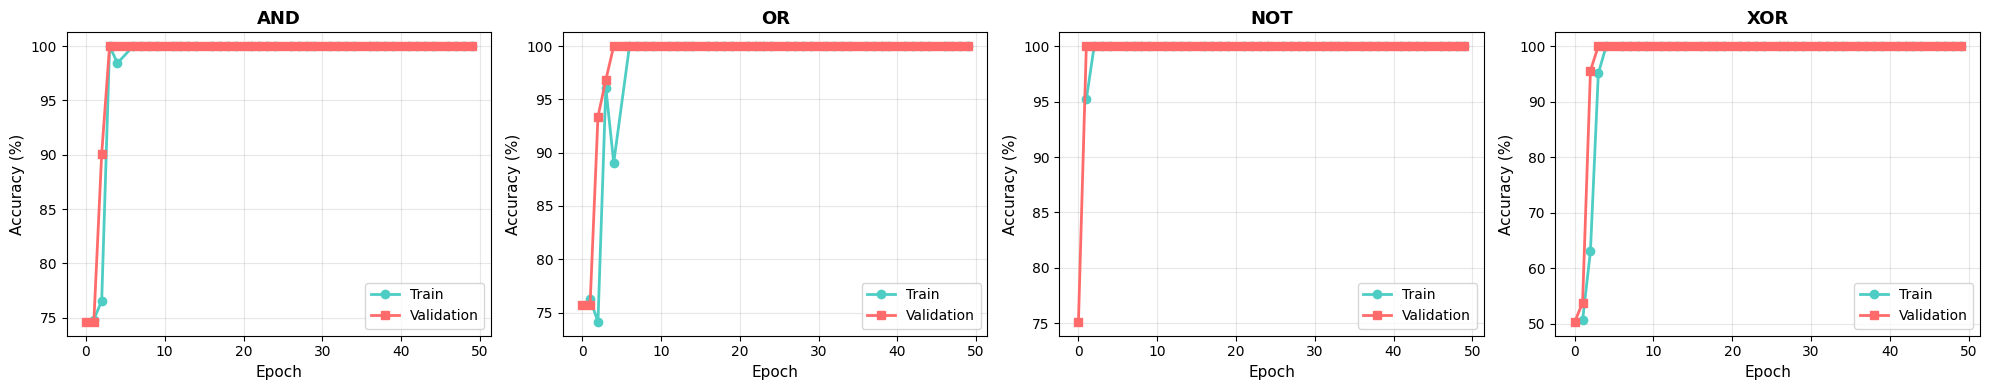


Final Loss Results:
------------------------------------------------------------
AND   - Train: 0.0000  Val: 0.0001
OR    - Train: 0.0000  Val: 0.0001
NOT   - Train: 0.0000  Val: 0.0001
XOR   - Train: 0.0002  Val: 0.0001


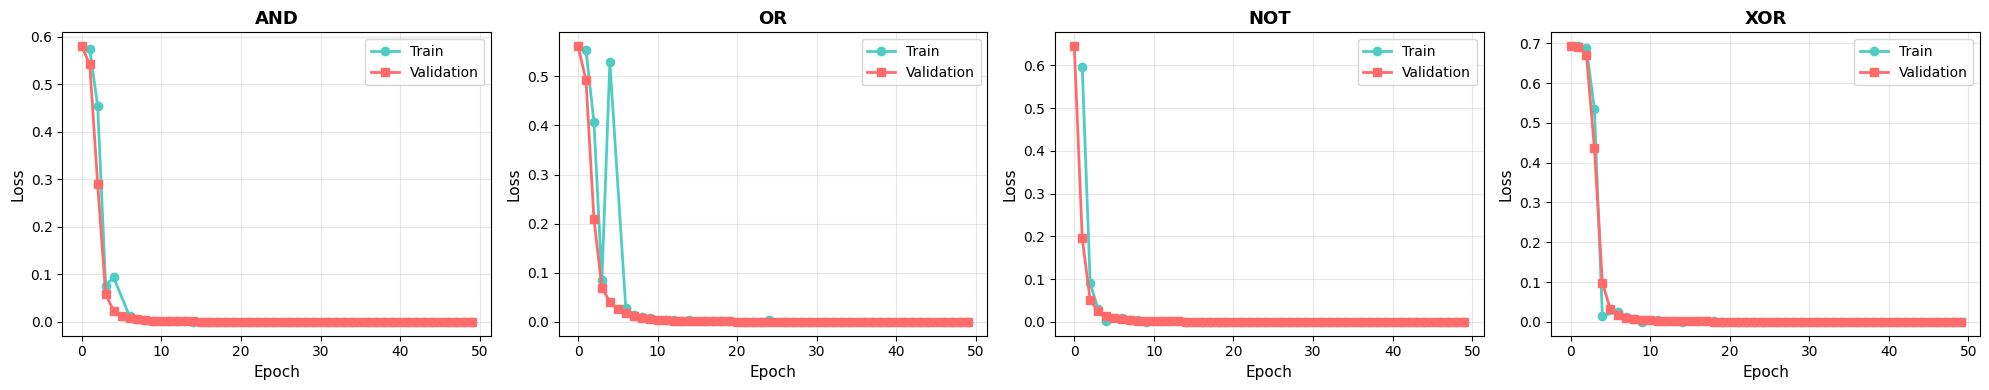

In [10]:
import pandas as pd

def plot_operation_comparison(results, metric='acc'):
    """
    Plot training curves for all operations side-by-side.
    
    Args:
        results: Dictionary with operation results
        metric: 'acc' or 'loss'
    """
    fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
    if len(results) == 1:
        axes = [axes]
    
    for idx, (operation, data) in enumerate(results.items()):
        logger = data['logger']
        trainer = data['trainer']
        
        # Read metrics
        metrics = pd.read_csv(f'{logger.log_dir}/metrics.csv')
        
        # Aggregate by epoch
        train_metrics = metrics[['epoch', f'train_{metric}']].dropna()
        val_metrics = metrics[['epoch', f'val_{metric}']].dropna()
        train_metrics = train_metrics.groupby('epoch').mean().reset_index()
        val_metrics = val_metrics.groupby('epoch').mean().reset_index()
        
        ax = axes[idx]
        
        # Plot curves
        if metric == 'acc':
            ax.plot(train_metrics['epoch'], train_metrics[f'train_{metric}'] * 100,
                   label='Train', marker='o', linewidth=2, color='#4ECDC4')
            ax.plot(val_metrics['epoch'], val_metrics[f'val_{metric}'] * 100,
                   label='Validation', marker='s', linewidth=2, color='#FF6B6B')
            ax.set_ylabel('Accuracy (%)', fontsize=11)
        else:
            ax.plot(train_metrics['epoch'], train_metrics[f'train_{metric}'],
                   label='Train', marker='o', linewidth=2, color='#4ECDC4')
            ax.plot(val_metrics['epoch'], val_metrics[f'val_{metric}'],
                   label='Validation', marker='s', linewidth=2, color='#FF6B6B')
            ax.set_ylabel('Loss', fontsize=11)
        
        ax.set_xlabel('Epoch', fontsize=11)
        ax.set_title(f'{operation}', fontsize=13, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Mark early stopping if triggered
        if trainer.early_stopping_callback and trainer.early_stopping_callback.stopped_epoch > 0:
            stop_epoch = trainer.early_stopping_callback.stopped_epoch
            ax.axvline(x=stop_epoch, color='red', linestyle='--', alpha=0.5)
        
        # Print final metrics
        final_train = train_metrics[f'train_{metric}'].iloc[-1]
        final_val = val_metrics[f'val_{metric}'].iloc[-1]
        
        if metric == 'acc':
            print(f"{operation:5s} - Train: {final_train*100:.1f}%  Val: {final_val*100:.1f}%  (Gap: {(final_train-final_val)*100:.1f}%)")
        else:
            print(f"{operation:5s} - Train: {final_train:.4f}  Val: {final_val:.4f}")
    
    plt.tight_layout()
    plt.show()

print("\nFinal Accuracy Results:")
print("-" * 60)
plot_operation_comparison(results, metric='acc')

print("\nFinal Loss Results:")
print("-" * 60)
plot_operation_comparison(results, metric='loss')

## 12. Test Model Predictions

Visualize what the trained models actually learned by showing predictions on new examples.

In [11]:
def visualize_predictions(model, operation, num_examples=5, seq_length=8):
    """
    Show model predictions on new examples.
    
    Args:
        model: Trained model
        operation: Operation name
        num_examples: Number of test cases to show
        seq_length: Length of sequences
    """
    model.eval()
    
    # Generate test data
    test_a, test_b, test_out = generate_binary_data(
        operation, num_examples, seq_length, seed=999
    )
    
    # Create inputs
    test_inputs = torch.stack([test_a, test_b], dim=2)  # (num_examples, seq_length, 2)
    
    # Get predictions
    with torch.no_grad():
        logits = model(test_inputs)
        predictions = (torch.sigmoid(logits) > 0.5).float()
    
    # Visualize
    print(f"\n{operation} Predictions:")
    print("=" * 70)
    
    for i in range(num_examples):
        a = test_a[i].numpy().astype(int)
        b = test_b[i].numpy().astype(int)
        true_out = test_out[i].numpy().astype(int)
        pred_out = predictions[i].numpy().astype(int)
        
        # Check if correct
        correct = "✓" if np.array_equal(true_out, pred_out) else "✗"
        
        if operation == 'NOT':
            print(f"{correct} NOT {a} = {pred_out} (expected: {true_out})")
        else:
            print(f"{correct} {a} {operation:3s} {b} = {pred_out} (expected: {true_out})")
    
    # Calculate accuracy
    accuracy = (predictions == test_out).float().mean().item() * 100
    print(f"\nAccuracy on test set: {accuracy:.1f}%")

# Test each trained model
for operation in CONFIG['operations']:
    model = results[operation]['model']
    visualize_predictions(model, operation, num_examples=5, seq_length=CONFIG['sequence_length'])


AND Predictions:
✓ [0 0 1 1 0 1 1 1] AND [1 0 0 1 0 1 0 1] = [0 0 0 1 0 1 0 1] (expected: [0 0 0 1 0 1 0 1])
✓ [1 1 0 1 1 0 0 0] AND [0 0 1 1 1 1 0 0] = [0 0 0 1 1 0 0 0] (expected: [0 0 0 1 1 0 0 0])
✓ [1 0 1 1 1 1 0 0] AND [0 0 0 1 1 1 1 0] = [0 0 0 1 1 1 0 0] (expected: [0 0 0 1 1 1 0 0])
✓ [0 0 0 1 0 1 0 1] AND [1 0 0 1 1 0 0 1] = [0 0 0 1 0 0 0 1] (expected: [0 0 0 1 0 0 0 1])
✓ [1 0 0 1 0 1 0 1] AND [0 1 0 0 1 1 1 0] = [0 0 0 0 0 1 0 0] (expected: [0 0 0 0 0 1 0 0])

Accuracy on test set: 100.0%

OR Predictions:
✓ [0 0 1 1 0 1 1 1] OR  [1 0 0 1 0 1 0 1] = [1 0 1 1 0 1 1 1] (expected: [1 0 1 1 0 1 1 1])
✓ [1 1 0 1 1 0 0 0] OR  [0 0 1 1 1 1 0 0] = [1 1 1 1 1 1 0 0] (expected: [1 1 1 1 1 1 0 0])
✓ [1 0 1 1 1 1 0 0] OR  [0 0 0 1 1 1 1 0] = [1 0 1 1 1 1 1 0] (expected: [1 0 1 1 1 1 1 0])
✓ [0 0 0 1 0 1 0 1] OR  [1 0 0 1 1 0 0 1] = [1 0 0 1 1 1 0 1] (expected: [1 0 0 1 1 1 0 1])
✓ [1 0 0 1 0 1 0 1] OR  [0 1 0 0 1 1 1 0] = [1 1 0 1 1 1 1 1] (expected: [1 1 0 1 1 1 1 1])

Accuracy on te

## 13. Learning Difficulty Analysis

Compare which operations were easiest and hardest to learn.


Learning Difficulty Analysis
Operation Final Acc (%) Final Loss  Epochs Trained  Epochs to 95%
      AND         100.0     0.0001              50              3
       OR         100.0     0.0001              50              3
      NOT         100.0     0.0001              50              1
      XOR         100.0     0.0001              50              2

💡 Lower 'Epochs to 95%' = Easier to learn


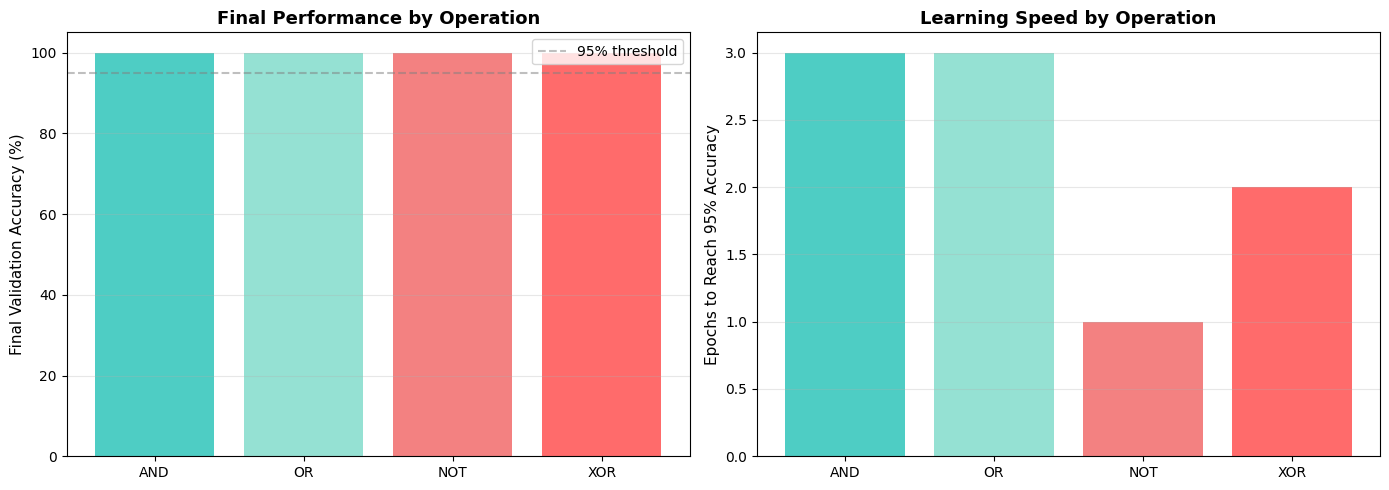

In [12]:
def analyze_learning_difficulty(results):
    """
    Analyze and rank operations by learning difficulty.
    """
    analysis = []
    
    for operation, data in results.items():
        logger = data['logger']
        trainer = data['trainer']
        
        # Read metrics
        metrics = pd.read_csv(f'{logger.log_dir}/metrics.csv')
        val_metrics = metrics[['epoch', 'val_acc', 'val_loss']].dropna()
        val_metrics = val_metrics.groupby('epoch').mean().reset_index()
        
        # Calculate statistics
        final_acc = val_metrics['val_acc'].iloc[-1] * 100
        final_loss = val_metrics['val_loss'].iloc[-1]
        epochs_trained = len(val_metrics)
        
        # Find epoch where 95% accuracy was reached
        epochs_to_95 = None
        for idx, row in val_metrics.iterrows():
            if row['val_acc'] >= 0.95:
                epochs_to_95 = int(row['epoch'])
                break
        
        analysis.append({
            'Operation': operation,
            'Final Acc (%)': f"{final_acc:.1f}",
            'Final Loss': f"{final_loss:.4f}",
            'Epochs Trained': epochs_trained,
            'Epochs to 95%': epochs_to_95 if epochs_to_95 else 'N/A'
        })
    
    # Create DataFrame and sort by epochs to 95%
    df = pd.DataFrame(analysis)
    
    print("\nLearning Difficulty Analysis")
    print("=" * 70)
    print(df.to_string(index=False))
    print("\n💡 Lower 'Epochs to 95%' = Easier to learn")
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    operations = df['Operation'].values
    final_accs = [float(x) for x in df['Final Acc (%)'].values]
    epochs_to_95 = [int(x) if x != 'N/A' else CONFIG['max_epochs'] for x in df['Epochs to 95%'].values]
    
    # Bar chart: Final accuracy
    colors = ['#4ECDC4', '#95E1D3', '#F38181', '#FF6B6B']
    ax1.bar(operations, final_accs, color=colors[:len(operations)])
    ax1.set_ylabel('Final Validation Accuracy (%)', fontsize=11)
    ax1.set_title('Final Performance by Operation', fontsize=13, fontweight='bold')
    ax1.axhline(y=95, color='gray', linestyle='--', alpha=0.5, label='95% threshold')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Bar chart: Epochs to 95%
    ax2.bar(operations, epochs_to_95, color=colors[:len(operations)])
    ax2.set_ylabel('Epochs to Reach 95% Accuracy', fontsize=11)
    ax2.set_title('Learning Speed by Operation', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

analyze_learning_difficulty(results)

## 14. Experiment: Change RNN Type

Compare different RNN architectures (vanilla RNN, LSTM, GRU) on the hardest operation (typically XOR).

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


GPU available: True (mps), used: True


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs



Training RNN on XOR

Training on XOR operation


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


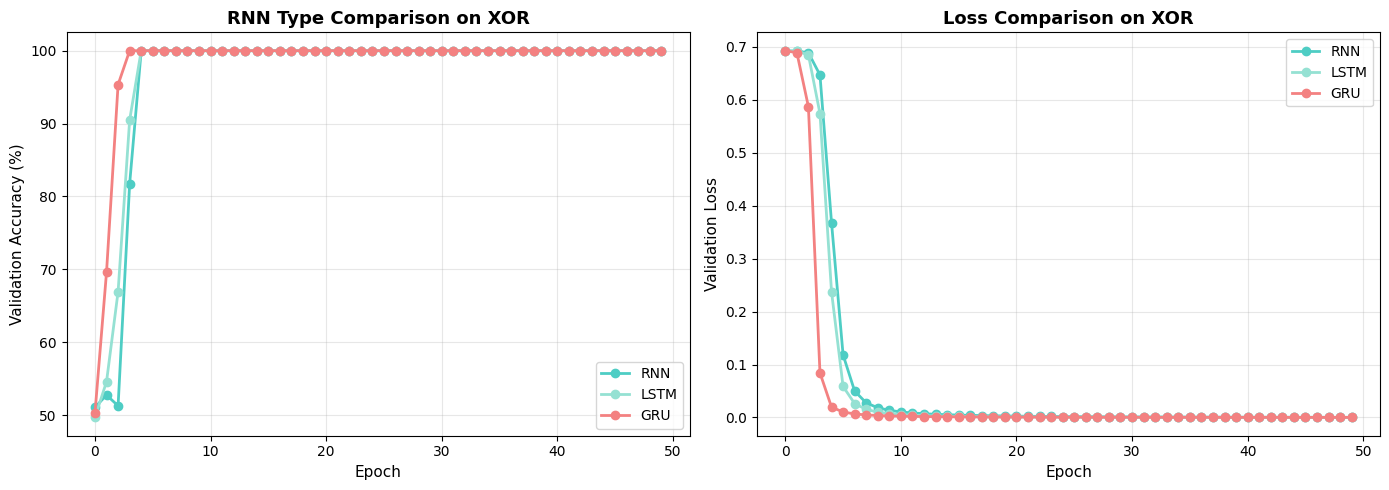

In [13]:
def compare_rnn_types(operation='XOR', rnn_types=['RNN', 'LSTM', 'GRU']):
    """
    Train models with different RNN types on the same operation.
    """
    comparison_results = {}
    
    for rnn_type in rnn_types:
        print(f"\n{'='*60}")
        print(f"Training {rnn_type} on {operation}")
        print(f"{'='*60}")
        
        # Create modified config
        exp_config = CONFIG.copy()
        exp_config['rnn_type'] = rnn_type
        
        # Train
        model, trainer, logger = train_binary_op_model(operation, exp_config)
        comparison_results[rnn_type] = {
            'model': model,
            'trainer': trainer,
            'logger': logger
        }
    
    # Plot comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = ['#4ECDC4', '#95E1D3', '#F38181']
    
    for idx, (rnn_type, data) in enumerate(comparison_results.items()):
        logger = data['logger']
        
        # Read metrics
        metrics = pd.read_csv(f'{logger.log_dir}/metrics.csv')
        val_metrics = metrics[['epoch', 'val_acc', 'val_loss']].dropna()
        val_metrics = val_metrics.groupby('epoch').mean().reset_index()
        
        # Plot
        ax1.plot(val_metrics['epoch'], val_metrics['val_acc'] * 100,
                label=rnn_type, marker='o', linewidth=2, color=colors[idx])
        ax2.plot(val_metrics['epoch'], val_metrics['val_loss'],
                label=rnn_type, marker='o', linewidth=2, color=colors[idx])
    
    ax1.set_xlabel('Epoch', fontsize=11)
    ax1.set_ylabel('Validation Accuracy (%)', fontsize=11)
    ax1.set_title(f'RNN Type Comparison on {operation}', fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.set_xlabel('Epoch', fontsize=11)
    ax2.set_ylabel('Validation Loss', fontsize=11)
    ax2.set_title(f'Loss Comparison on {operation}', fontsize=13, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return comparison_results

# Compare on the hardest operation
rnn_comparison = compare_rnn_types(operation='XOR', rnn_types=['RNN', 'LSTM', 'GRU'])

## 15. Experiment: Vary Hidden Size

Test how model capacity affects learning by varying hidden size.

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


GPU available: True (mps), used: True


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs



Training with hidden_size=16...

Training on XOR operation


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


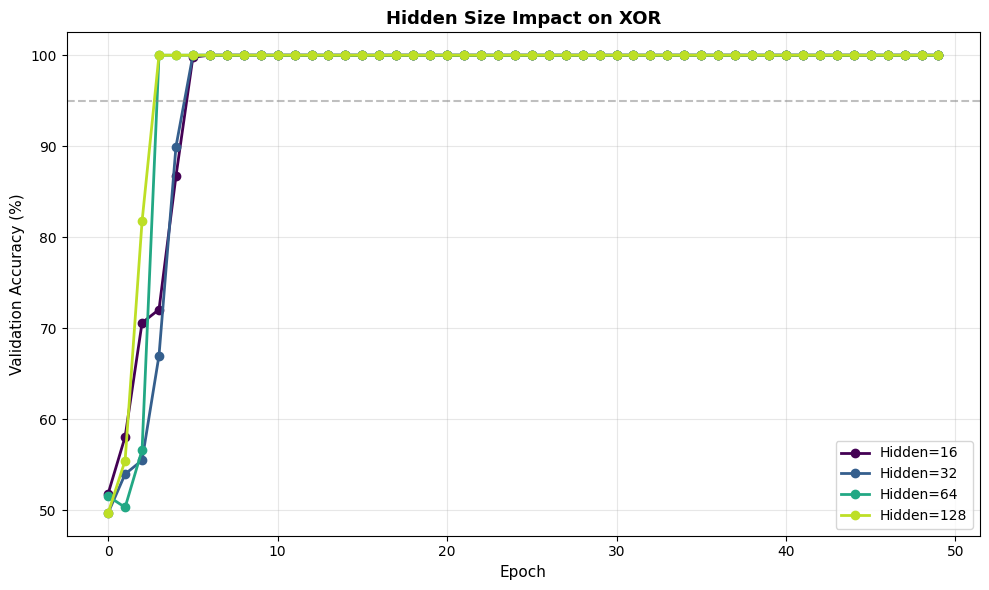

In [14]:
def compare_hidden_sizes(operation='XOR', hidden_sizes=[16, 32, 64, 128]):
    """
    Train models with different hidden sizes on the same operation.
    """
    size_results = {}
    
    for hidden_size in hidden_sizes:
        print(f"\nTraining with hidden_size={hidden_size}...")
        
        # Create modified config
        exp_config = CONFIG.copy()
        exp_config['hidden_size'] = hidden_size
        
        # Train
        model, trainer, logger = train_binary_op_model(operation, exp_config)
        size_results[hidden_size] = {
            'model': model,
            'trainer': trainer,
            'logger': logger
        }
    
    # Plot comparison
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(hidden_sizes)))
    
    for idx, (hidden_size, data) in enumerate(size_results.items()):
        logger = data['logger']
        
        # Read metrics
        metrics = pd.read_csv(f'{logger.log_dir}/metrics.csv')
        val_metrics = metrics[['epoch', 'val_acc']].dropna()
        val_metrics = val_metrics.groupby('epoch').mean().reset_index()
        
        # Plot
        ax.plot(val_metrics['epoch'], val_metrics['val_acc'] * 100,
               label=f'Hidden={hidden_size}', marker='o', linewidth=2, color=colors[idx])
    
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Validation Accuracy (%)', fontsize=11)
    ax.set_title(f'Hidden Size Impact on {operation}', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axhline(y=95, color='gray', linestyle='--', alpha=0.5, label='95% threshold')
    
    plt.tight_layout()
    plt.show()
    
    return size_results

# Compare hidden sizes
hidden_size_comparison = compare_hidden_sizes(operation='XOR', hidden_sizes=[16, 32, 64, 128])

## 16. Experiment: Sequence Length Generalization

Test if models trained on short sequences can generalize to longer ones.


Length Generalization for XOR
 Length  Accuracy Trained
      4     100.0        
      8     100.0       ✓
     12     100.0        
     16     100.0        
     20     100.0        


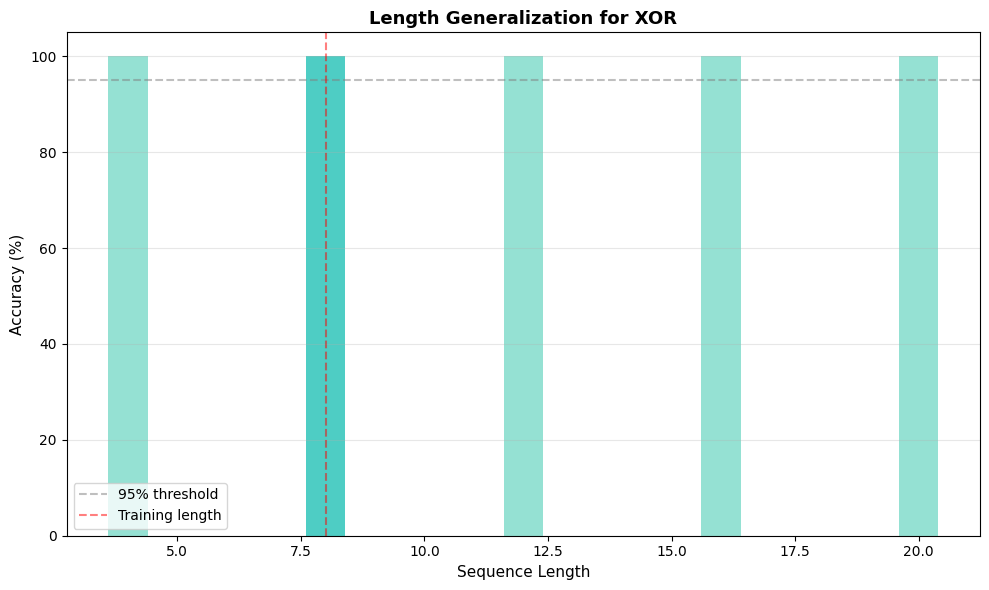

In [15]:
def test_length_generalization(model, operation, train_length, test_lengths):
    """
    Test model on different sequence lengths.
    
    Args:
        model: Trained model
        operation: Operation name
        train_length: Length model was trained on
        test_lengths: List of lengths to test
    """
    model.eval()
    results = []
    
    for length in test_lengths:
        # Generate test data
        test_a, test_b, test_out = generate_binary_data(
            operation, 500, length, seed=888
        )
        
        # Create dataset and loader
        test_dataset = BinaryOpDataset(test_a, test_b, test_out)
        test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
        
        # Evaluate
        correct = 0
        total = 0
        
        with torch.no_grad():
            for x, y in test_loader:
                logits = model(x)
                preds = (torch.sigmoid(logits) > 0.5).float()
                correct += (preds == y).sum().item()
                total += y.numel()
        
        accuracy = correct / total * 100
        results.append({
            'Length': length,
            'Accuracy': accuracy,
            'Trained': '✓' if length == train_length else ''
        })
    
    # Print results
    df = pd.DataFrame(results)
    print(f"\nLength Generalization for {operation}")
    print("=" * 50)
    print(df.to_string(index=False))
    
    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    lengths = df['Length'].values
    accuracies = df['Accuracy'].values
    colors = ['#4ECDC4' if l == train_length else '#95E1D3' for l in lengths]
    
    ax.bar(lengths, accuracies, color=colors)
    ax.axhline(y=95, color='gray', linestyle='--', alpha=0.5, label='95% threshold')
    ax.axvline(x=train_length, color='red', linestyle='--', alpha=0.5, label='Training length')
    ax.set_xlabel('Sequence Length', fontsize=11)
    ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.set_title(f'Length Generalization for {operation}', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

# Test XOR model on different lengths
xor_model = results['XOR']['model']
test_length_generalization(
    xor_model,
    'XOR',
    train_length=CONFIG['sequence_length'],
    test_lengths=[4, 8, 12, 16, 20]
)

## 17. Key Takeaways

**What we learned:**

1. **Operation Difficulty Hierarchy**: 
   - AND, OR, NOT are linearly separable → Easy to learn
   - XOR is non-linearly separable → Requires more capacity and epochs

2. **RNN Architecture Matters**:
   - LSTMs and GRUs typically outperform vanilla RNNs on harder tasks
   - Gating mechanisms help with gradient flow and learning complex patterns

3. **Model Capacity**:
   - Small hidden sizes (16-32) sufficient for simple operations
   - XOR benefits from larger hidden sizes (64+)

4. **Generalization**:
   - Models can generalize to longer sequences than trained on
   - Bit-level operations don't require position-specific learning

5. **Test Bed Value**:
   - Binary operations provide fast, controlled experiments
   - Perfect for prototyping RNN architectures and hyperparameters
   - Clear success metric (accuracy) makes debugging easier

**Next Steps:**
- Try multi-bit operations (addition, multiplication)
- Test on variable-length sequences
- Compare with Transformer architectures
- Explore attention mechanisms for interpretability